In [1]:
import os
import numpy as np
import pandas as pd
import random
import glob
import shutil
import time
import cv2

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from numpy.random import seed
from tensorflow.random import set_seed
seed(1)
set_seed(2)

import matplotlib.pyplot as plt
from skimage import io


2025-09-15 03:59:37.919278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757908778.095343      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757908778.143003      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
base_path = '/kaggle/input/foodydudy/kaggle/train'
classes = os.listdir(base_path)
filepaths = []
labels = []
for c in classes:
    flist = os.listdir(base_path + '/' + c)
    for f in flist:
        fpath = os.path.join(base_path, c, f)
        filepaths.append(fpath)
        labels.append(c)
print ('filepaths: ', len(filepaths), '   labels: ', len(labels))


filepaths:  11520    labels:  11520


In [3]:
Fseries=pd.Series(filepaths, name='file_paths')
Lseries=pd.Series(labels, name='labels')
train_df=pd.concat([Fseries,Lseries], axis=1)
train_df=pd.DataFrame(train_df, columns = ['file_paths', 'labels'])
print(train_df['labels'].value_counts())

labels
47    240
17    240
19    240
22    240
35    240
23    240
07    240
10    240
36    240
05    240
20    240
06    240
45    240
27    240
41    240
39    240
02    240
32    240
25    240
42    240
38    240
12    240
04    240
31    240
34    240
18    240
28    240
16    240
13    240
26    240
00    240
08    240
15    240
43    240
09    240
30    240
14    240
03    240
46    240
21    240
44    240
40    240
11    240
37    240
01    240
33    240
29    240
24    240
Name: count, dtype: int64


In [4]:
base_path = '/kaggle/input/foodydudy/kaggle/valid'
classes = os.listdir(base_path)
filepaths = []
labels = []
for c in classes:
    flist = os.listdir(base_path + '/' + c)
    for f in flist:
        fpath = os.path.join(base_path, c, f)
        filepaths.append(fpath)
        labels.append(c)
print ('filepaths: ', len(filepaths), '   labels: ', len(labels))

filepaths:  1440    labels:  1440


In [5]:
Fseries=pd.Series(filepaths, name='file_paths')
Lseries=pd.Series(labels, name='labels')
valid_df=pd.concat([Fseries,Lseries], axis=1)
valid_df=pd.DataFrame(valid_df, columns = ['file_paths', 'labels'])
print(valid_df['labels'].value_counts())

labels
47    30
17    30
19    30
22    30
35    30
23    30
07    30
10    30
36    30
05    30
20    30
06    30
45    30
27    30
41    30
39    30
02    30
32    30
25    30
42    30
38    30
12    30
04    30
31    30
34    30
18    30
28    30
16    30
13    30
26    30
00    30
08    30
15    30
43    30
09    30
30    30
14    30
03    30
46    30
21    30
44    30
40    30
11    30
37    30
01    30
33    30
29    30
24    30
Name: count, dtype: int64


In [6]:
base_path = '/kaggle/input/foodydudy/kaggle/test'
classes = os.listdir(base_path)
filepaths = []
labels = []
for c in classes:
    flist = os.listdir(base_path + '/' + c)
    for f in flist:
        fpath = os.path.join(base_path, c, f)
        filepaths.append(fpath)
        labels.append(c)
print ('filepaths: ', len(filepaths), '   labels: ', len(labels))

filepaths:  1440    labels:  1440


In [7]:
Fseries=pd.Series(filepaths, name='file_paths')
Lseries=pd.Series(labels, name='labels')
test_df=pd.concat([Fseries,Lseries], axis=1)
test_df=pd.DataFrame(test_df, columns = ['file_paths', 'labels'])
print(test_df['labels'].value_counts())

labels
47    30
17    30
19    30
22    30
35    30
23    30
07    30
10    30
36    30
05    30
20    30
06    30
45    30
27    30
41    30
39    30
02    30
32    30
25    30
42    30
38    30
12    30
04    30
31    30
34    30
18    30
28    30
16    30
13    30
26    30
00    30
08    30
15    30
43    30
09    30
30    30
14    30
03    30
46    30
21    30
44    30
40    30
11    30
37    30
01    30
33    30
29    30
24    30
Name: count, dtype: int64


In [8]:
img = plt.imread('/kaggle/input/foodydudy/kaggle/test/00/0271.jpg')
img.shape

(224, 224, 3)

In [9]:
target_size=(224,224)
batch_size=256

In [10]:
train_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input)
train_gen = train_datagen.flow_from_dataframe(train_df, x_col='file_paths', y_col='labels', target_size=target_size, batch_size=batch_size, color_mode='rgb', class_mode='categorical')
valid_gen = test_datagen.flow_from_dataframe(valid_df, x_col='file_paths', y_col='labels', target_size=target_size, batch_size=batch_size, color_mode='rgb', class_mode='categorical')
test_gen = test_datagen.flow_from_dataframe(test_df, x_col='file_paths', y_col='labels', target_size=target_size, batch_size=batch_size, color_mode='rgb', class_mode='categorical')

Found 11520 validated image filenames belonging to 48 classes.
Found 1440 validated image filenames belonging to 48 classes.
Found 1440 validated image filenames belonging to 48 classes.


In [11]:
# ฟังก์ชัน F1-score
def f1_score(y_true, y_pred):
    y_pred = K.round(y_pred)  # ปัดค่าความน่าจะเป็นเป็น 0/1
    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

In [12]:
base_model = tf.keras.applications.EfficientNetB0(include_top=False, input_shape=(224,224,3), weights='imagenet')
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(48, activation='softmax')
])



I0000 00:00:1757908805.590185      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='roc_auc'),
        f1_score
    ]
)


In [15]:
patience = 2
stop_patience = 5
factor = 0.5

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/classify_model.keras",  # ใช้นามสกุลใหม่
        save_best_only=True,
        
        verbose=0
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=stop_patience,
        monitor='val_loss',
        verbose=1,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=factor,
        patience=patience,
        verbose=1
    )
]

In [16]:
epochs = 20
history = model.fit(train_gen, validation_data=valid_gen, epochs=epochs, callbacks=callbacks, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1757909018.355421      81 service.cc:148] XLA service 0x7ac23c004cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757909018.356165      81 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757909023.776822      81 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1757909038.499231      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757909038.719802      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757909039.843328      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757909040.0440

45/45 ━━━━━━━━━━━━━━━━━━━━ 302s 4s/step - accuracy: 0.3881 - f1_score: 0.2595 - loss: 2.5446 - precision: 0.7815 - recall: 0.2129 - roc_auc: 0.8464 - val_accuracy: 0.5771 - val_f1_score: 0.4248 - val_loss: 1.5030 - val_precision: 0.7213 - val_recall: 0.3792 - val_roc_auc: 0.9646 - learning_rate: 0.0010
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9061 - f1_score: 0.8834 - loss: 0.3723 - precision: 0.9584 - recall: 0.8384 - roc_auc: 0.9983 - val_accuracy: 0.8660 - val_f1_score: 0.8414 - val_loss: 0.4940 - val_precision: 0.9295 - val_recall: 0.8062 - val_roc_auc: 0.9948 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.9674 - f1_score: 0.9571 - loss: 0.1468 - precision: 0.9804 - recall: 0.9459 - roc_auc: 0.9996 - val_accuracy: 0.9174 - val_f1_score: 0.8900 - val_loss: 0.3331 - val_precision: 0.9415 - val_recall: 0.8715 - val_roc_auc: 0.9974 - learning_rate: 0.0010
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9

In [17]:
def plot_history(history):
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    titles = {
        'accuracy': 'Accuracy',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1_score': 'F1 Score',
        'roc_auc': 'ROC AUC',
        'loss': 'Loss'
    }

    plt.figure(figsize=(16,10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 3, i+1)
        plt.plot(history.history[metric], label=f"train_{metric}")
        plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        plt.xlabel("Epochs")
        plt.ylabel(metric.capitalize())
        plt.title(titles[metric])
        plt.legend()
        plt.grid(True)

    # วาด loss ด้วย
    plt.subplot(2, 3, 6)
    plt.plot(history.history['loss'], label="train_loss")
    plt.plot(history.history['val_loss'], label="val_loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(titles['loss'])
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


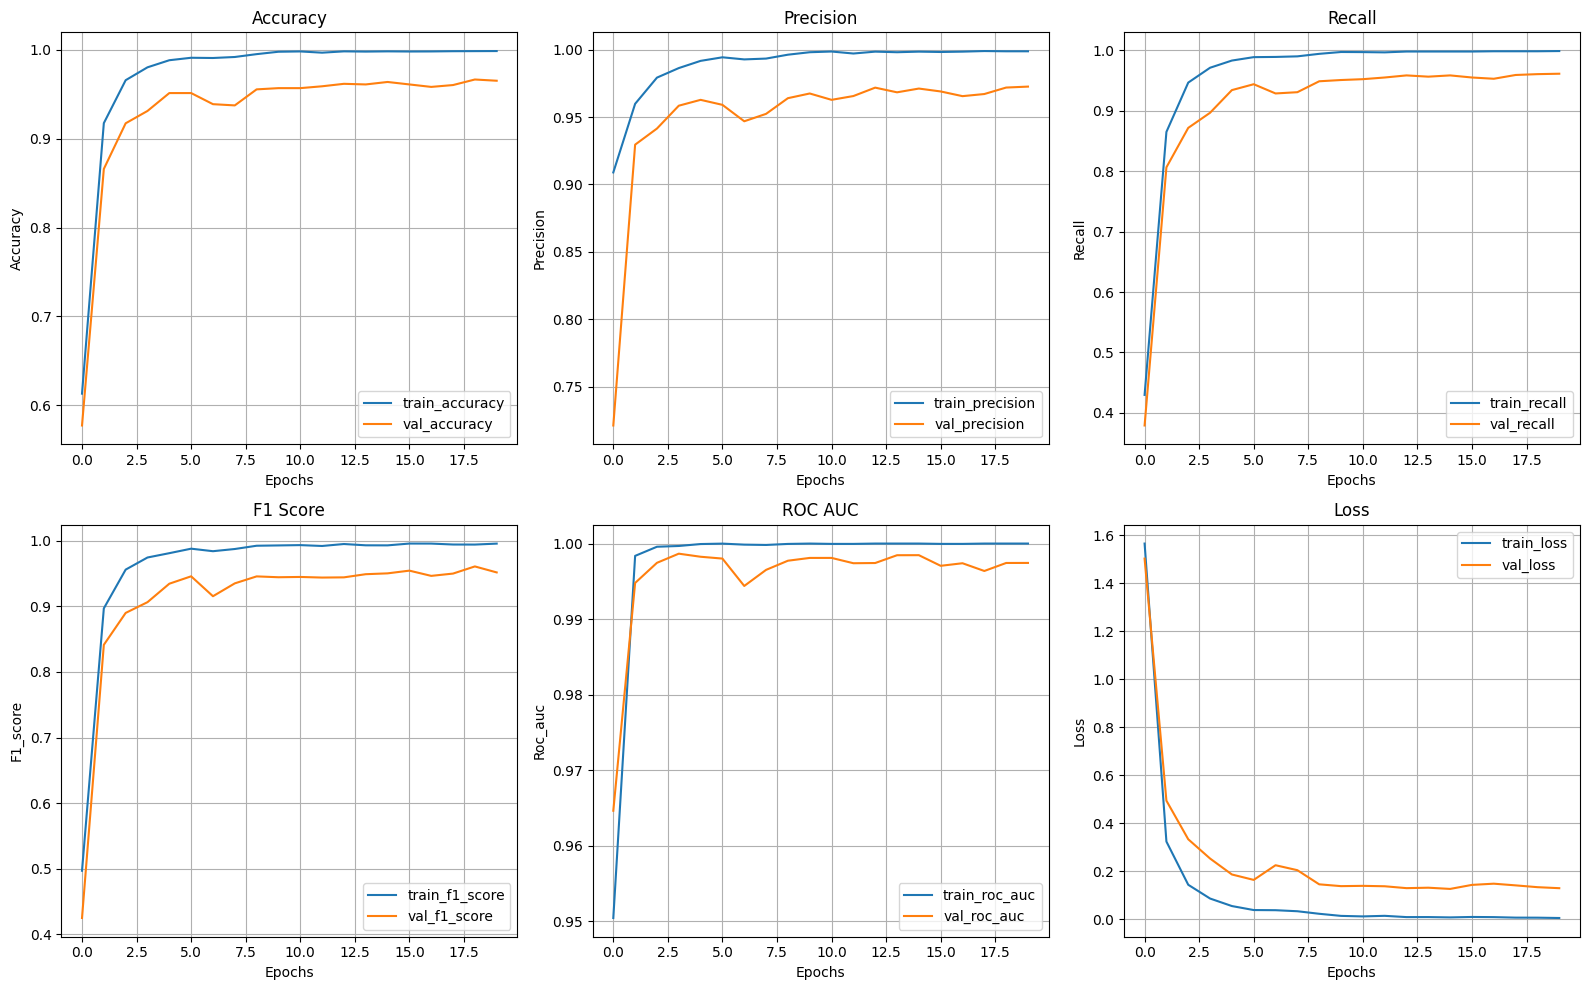

In [18]:
plot_history(history)


In [19]:
best_model = model
best_model.load_weights('/kaggle/working/classify_model.keras')
model_MBN = best_model 
best_model.evaluate(test_gen)

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9644 - f1_score: 0.9530 - loss: 0.1322 - precision: 0.9715 - recall: 0.9598 - roc_auc: 0.9975


[0.1506320983171463,
 0.9618055820465088,
 0.9697396159172058,
 0.956944465637207,
 0.9966789484024048,
 0.9494319558143616]

/tmp/ipykernel_36/3544333417.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', n_classes)


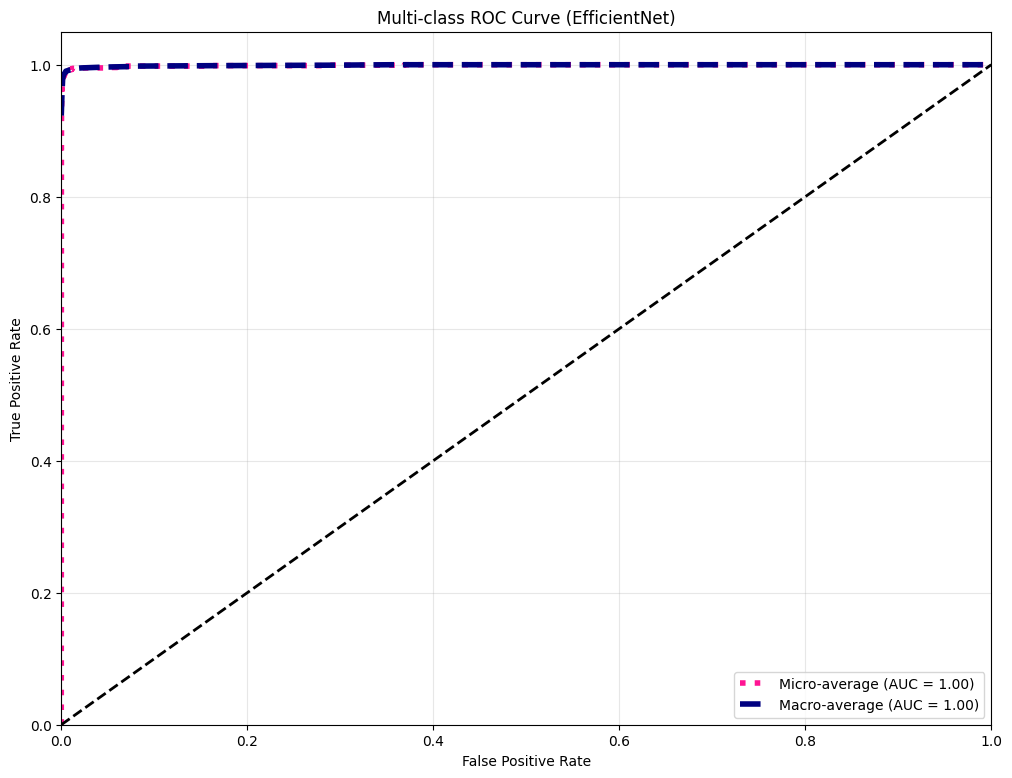

Predicted correctly: 1385/1440 (96.18%)


In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# --- STEP 0: ฟังก์ชันเตรียมรูปภาพสำหรับ EfficientNet ---
def prepare_image(path, model_name='efficientnet'):
    from tensorflow.keras.applications.efficientnet import preprocess_input
    try:
        img = cv2.imread(path)
        if img is None:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))  # ขนาด input ของ EfficientNet
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        return img
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

# --- STEP 1: Prediction + เก็บ Label จริง ---
y_scores = []
true_labels = []

for path, label in zip(test_df['file_paths'], test_df['labels']):
    img = prepare_image(path, 'efficientnet')
    if img is None:
        continue
    prob = model_MBN.predict(img, verbose=0)[0]
    y_scores.append(prob)
    true_labels.append(label)

y_scores = np.array(y_scores)
true_labels = np.array(true_labels)

# --- STEP 2: Map label → index ---
unique_labels = np.unique(true_labels)
label_to_index = {label: i for i, label in enumerate(unique_labels)}
true_indexed = np.array([label_to_index[l] for l in true_labels])

# --- STEP 3: One-hot encode ---
y_true_bin = label_binarize(true_indexed, classes=np.arange(len(unique_labels)))
n_classes = len(unique_labels)

# --- STEP 4: ROC per class + micro + macro ---
fpr, tpr, roc_auc = {}, {}, {}

# ROC แต่ละคลาส
for i in range(n_classes):
    if np.sum(y_true_bin[:, i]) == 0:   # กัน error ถ้าไม่มีคลาสนี้ใน test set
        fpr[i], tpr[i], roc_auc[i] = None, None, None
        continue
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes) if fpr[i] is not None]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    if fpr[i] is not None:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# --- STEP 5: Plot ROC ---
plt.figure(figsize=(12, 9))
colors = plt.cm.get_cmap('tab20', n_classes)

# Micro-average ROC
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Macro-average ROC
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle='--', linewidth=4)


# เส้น random guess
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (EfficientNet)')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# --- STEP 6: Accuracy ---
y_pred = np.argmax(y_scores, axis=1)  
correct = (y_pred == true_indexed)
num_correct = np.sum(correct)
total = len(true_indexed)
accuracy = num_correct / total
print(f"Predicted correctly: {num_correct}/{total} ({accuracy*100:.2f}%)")